<a href="https://colab.research.google.com/github/IGol22/SFML/blob/main/%D0%9A%D1%83%D1%80%D1%81%D0%BE%D0%B2%D0%B0%D1%8F/0_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Загрузка датасета
file_name = "dataset_classic_ML.xlsx"
if not os.path.exists(file_name):
    raw_url = "https://raw.githubusercontent.com/IGol22/SFML/main/Курсовая/dataset_classic_ML.xlsx"
    !wget -q -O {file_name} "{raw_url}"

df = pd.read_excel(file_name)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(f"Размерность датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Пропуски в данных: {df.isnull().sum().sum()}")
df.info()

Размерность датасета: 1001 строк, 213 столбцов
Пропуски в данных: 36
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


--- Статистика целевых переменных ---


,"IC50, mM","CC50, mM",SI
count,1001.0000,1001.0000,1001.0000
mean,222.8052,589.1107,72.5088
std,402.1697,642.8675,684.4827
min,0.0035,0.7008,0.0115
25%,12.5154,99.9990,1.4333
50%,46.5852,411.0393,3.8462
75%,224.9759,894.0892,16.5667
max,4128.5294,4538.9762,15620.6000



---Skewness ---
IC50, mM: 3.6694
CC50, mM: 1.9704
SI: 17.9862


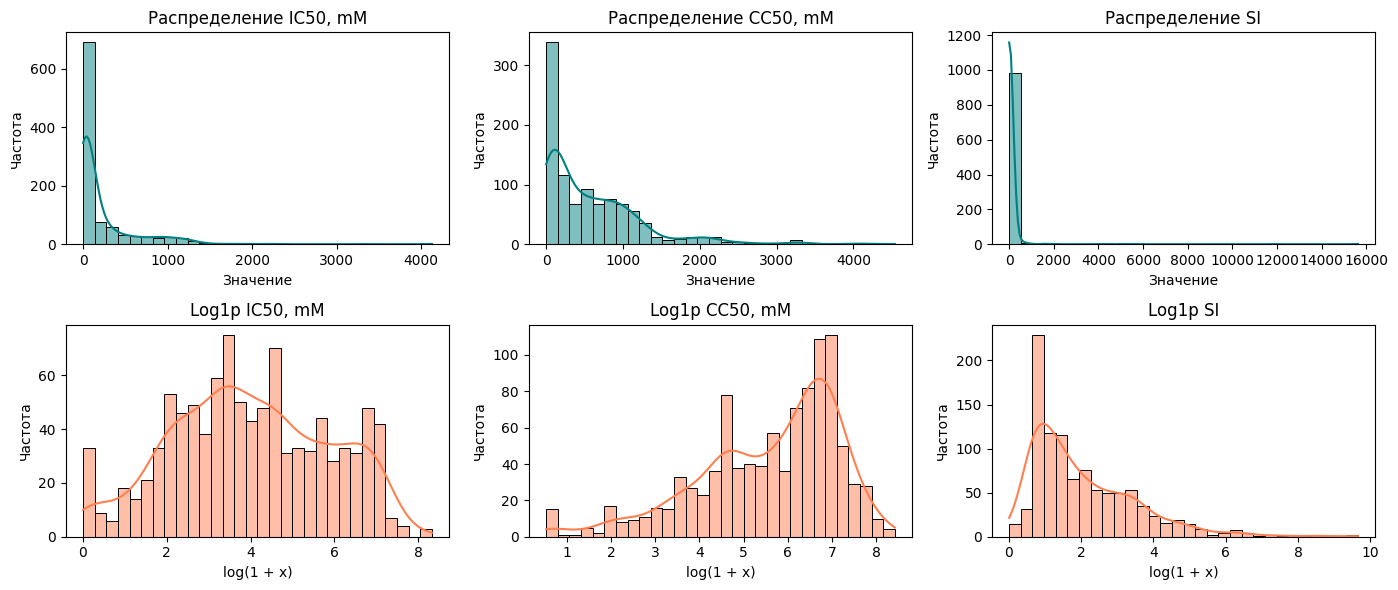

In [6]:
targets = ['IC50, mM', 'CC50, mM', 'SI']

# Описание таргетов
print("--- Статистика целевых переменных ---")
display(df[targets].describe().round(4))

# Проверка асимметрии
print("\n---Skewness ---")
for t in targets:
    print(f"{t}: {stats.skew(df[t].dropna()):.4f}")

# График (распределение до и после log1p)
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for i, col in enumerate(targets):
    # Верхний ряд (исходные)
    sns.histplot(df[col], kde=True, ax=axes[0, i], bins=30, color='teal')
    axes[0, i].set_title(f'Распределение {col}')
    axes[0, i].set_xlabel('Значение')
    axes[0, i].set_ylabel('Частота')

    # Нижний ряд (log1p)
    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[1, i], bins=30, color='coral')
    axes[1, i].set_title(f'Log1p {col}')
    axes[1, i].set_xlabel('log(1 + x)')
    axes[1, i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Признаков с нулевой дисперсией: 18
Признаков с дисперсией < 0.01: 34

Top-10 признаков по корреляции с IC50:


,"IC50, mM"
"CC50, mM",0.521
VSA_EState4,0.274
Chi2n,0.257
PEOE_VSA7,0.256
Chi2v,0.249
fr_Ar_NH,0.246
fr_Nhpyrrole,0.246
Chi4v,0.244
Chi4n,0.243
Chi3n,0.240



Top-10 признаков по корреляции с CC50:


,"CC50, mM"
"IC50, mM",0.521
MolMR,0.310
LabuteASA,0.309
MolWt,0.306
ExactMolWt,0.306
HeavyAtomCount,0.305
Chi0,0.305
Chi1,0.304
HeavyAtomMolWt,0.303
Kappa1,0.302



Top-10 признаков по корреляции с SI:


,SI
BalabanJ,0.163
fr_NH2,0.160
RingCount,0.124
fr_Al_COO,0.102
fr_COO2,0.101
fr_COO,0.101
NumAromaticRings,0.088
VSA_EState4,0.088
FpDensityMorgan1,0.087
VSA_EState6,0.083


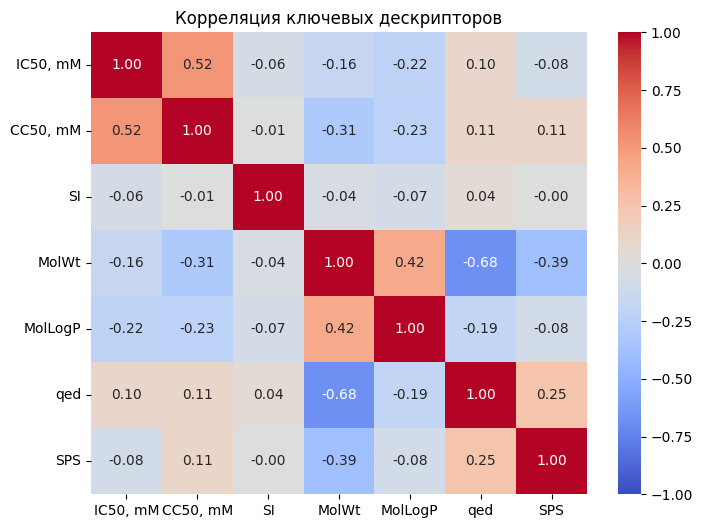

In [8]:
features = df.drop(columns=targets, errors='ignore')

# Поиск признаков с низкой вариацией
variances = features.var()
zero_var_cols = variances[variances == 0].index.tolist()
low_var_cols = variances[variances < 0.01].index.tolist()

print(f"Признаков с нулевой дисперсией: {len(zero_var_cols)}")
print(f"Признаков с дисперсией < 0.01: {len(low_var_cols)}")

# Топ корреляций с таргетами
corr_matrix = df.corr(numeric_only=True)

print("\nTop-10 признаков по корреляции с IC50:")
display(corr_matrix['IC50, mM'].abs().sort_values(ascending=False)[1:11].to_frame().round(3))

print("\nTop-10 признаков по корреляции с CC50:")
display(corr_matrix['CC50, mM'].abs().sort_values(ascending=False)[1:11].to_frame().round(3))

print("\nTop-10 признаков по корреляции с SI:")
display(corr_matrix['SI'].abs().sort_values(ascending=False)[1:11].to_frame().round(3))

# Матрица корреляции для ключевых параметров
key_cols = ['IC50, mM', 'CC50, mM', 'SI', 'MolWt', 'MolLogP', 'qed', 'SPS']
present_keys = [c for c in key_cols if c in df.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(df[present_keys].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция ключевых дескрипторов')
plt.show()

## Итоги EDA

* **Данные:** В датасете 1001 запись и 215 колонок (2D-дескрипторы RDKit). Пропусков нет, матрица чистая.
* **Таргеты:** У всех трех показателей ($IC_{50}$, $CC_{50}$, $SI$) сильный перекос вправо (skewness > 2) и длинные «хвосты» из выбросов. Из-за этого чистая регрессия работает плохо, и нужно логарифмировать значения (`log1p`) либо переходить к классификации.
* **Признаки:** Около 40 дескрипторов (в основном структурные `fr_*`) практически константны (дисперсия < 0.01). Их стоит дропать через `VarianceThreshold`, чтобы не замусоривать модели.
* **Корреляции:** Сильнее всего с активностью и токсичностью связаны молекулярный вес (`MolWt`) и липофильность (`MolLogP`). На этапе Feature Engineering из них логично собрать перекрестные признаки.